## Problem 1
### Part 1

In [2]:
import sympy as sp
from sympy import symbols, pprint, Function, simplify, Derivative, nsimplify
from sympy import sin, cos, asin, acos, pi, diff, eye
from sympy import Matrix, latex, BlockMatrix, lambdify
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import init_printing
init_printing() 

# Define Symbols
t  = symbols("t",   real=True)
l = symbols("l",  real=True)   # Length of Link, assume Links are same length
m = symbols("m", real=True)
k = symbols("k", real=True) # Drag Coefficient
d = symbols("d",real=True)
# Config Variables
x     = Function('x',     real=True)(t)
y     = Function('y',     real=True)(t)
theta = Function('theta', real=True)(t)
a1    = Function('a1',real=True)(t)
a2    = Function('a2',real=True)(t)
## Alpha Kinematics
omega = symbols("omega",real=True)
A1 = symbols("A1",real=True)
A2 = symbols("A2",real=True)
phi = symbols("phi",real=True)


In [3]:
# Defining Various Helper Functions
def cross_matrix(vec):
    
    return Matrix([[0, -vec[2,0], vec[1,0]],
                      [vec[2,0], 0, -vec[0,0]],
                      [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    
    return Matrix([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    
    return(m)
    
def R_z(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta), -sin(theta), 0], 
                   [sin(theta), cos(theta), 0],
                   [0, 0, 1]])

def R_y(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta),0, sin(theta)], 
                   [0, 1, 0],
                   [-sin(theta), 0, cos(theta)]])

def R_x(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta), cos(theta)]])
def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m


In [4]:
# Transform to Joint 1, then Translate to COM 1
T0COM1   = T(R_z(theta), Matrix([[x],[y],[0]]))

TJ1rot = T(R_z(pi-a1),Matrix([[-l/2],[0],[0]]))
TJ1COM2 = T(eye(3),Matrix([[l/2],[0],[0]]))
T0COM2= simplify(T0COM1 @ TJ1rot @ TJ1COM2)

TJ2rot = (T(R_z(a2),Matrix([[l/2],[0],[0]])))
TJ2COM3 = T(eye(3),Matrix([[l/2],[0],[0]]))
T0COM3= simplify(T0COM1 @  TJ2rot @ TJ2COM3)


In [5]:
T0COM1

⎡cos(θ(t))  -sin(θ(t))  0  x(t)⎤
⎢                              ⎥
⎢sin(θ(t))  cos(θ(t))   0  y(t)⎥
⎢                              ⎥
⎢    0          0       1   0  ⎥
⎢                              ⎥
⎣    0          0       0   1  ⎦

In [6]:
T0COM2

⎡                                             l⋅cos(a₁(t) - θ(t))   l⋅cos(θ(t))       ⎤
⎢-cos(a₁(t) - θ(t))  -sin(a₁(t) - θ(t))  0  - ─────────────────── - ─────────── + x(t)⎥
⎢                                                      2                 2            ⎥
⎢                                                                                     ⎥
⎢                                            l⋅sin(a₁(t) - θ(t))   l⋅sin(θ(t))        ⎥
⎢sin(a₁(t) - θ(t))   -cos(a₁(t) - θ(t))  0   ─────────────────── - ─────────── + y(t) ⎥
⎢                                                     2                 2             ⎥
⎢                                                                                     ⎥
⎢        0                   0           1                      0                     ⎥
⎢                                                                                     ⎥
⎣        0                   0           0                      1                     ⎦

In [7]:
T0COM3

⎡                                          l⋅cos(a₂(t) + θ(t))   l⋅cos(θ(t))       ⎤
⎢cos(a₂(t) + θ(t))  -sin(a₂(t) + θ(t))  0  ─────────────────── + ─────────── + x(t)⎥
⎢                                                   2                 2            ⎥
⎢                                                                                  ⎥
⎢                                          l⋅sin(a₂(t) + θ(t))   l⋅sin(θ(t))       ⎥
⎢sin(a₂(t) + θ(t))  cos(a₂(t) + θ(t))   0  ─────────────────── + ─────────── + y(t)⎥
⎢                                                   2                 2            ⎥
⎢                                                                                  ⎥
⎢        0                  0           1                     0                    ⎥
⎢                                                                                  ⎥
⎣        0                  0           0                     1                    ⎦

### Part 2 Compute Body Twists for each COM

In [8]:
# Define q, qdt, qdtdt
q= [x,y,theta,a1,a2]
q_dt= [Derivative(qq,t) for qq in q]
q_dtdt= [Derivative(qq,t,t) for qq in q]

# Body Twist For Each COM
bodytwist_COM1 = simplify(T0COM1.inv() @ diff(T0COM1, t))
bodytwist_COM1 = twist2vec(bodytwist_COM1) # Vectorized Bodytwist for COM 1
bodytwist_COM2 = simplify(T0COM2.inv() @ diff(T0COM2, t))
bodytwist_COM2 = twist2vec(bodytwist_COM2) # Vectorized Bodytwist for COM 2
bodytwist_COM3 = simplify(T0COM3.inv() @ diff(T0COM3, t))
bodytwist_COM3 = twist2vec(bodytwist_COM3) # Vectorized Bodytwist for COM 3

In [9]:
bodytwist_COM1

⎡                    0                    ⎤
⎢                                         ⎥
⎢                    0                    ⎥
⎢                                         ⎥
⎢                d                        ⎥
⎢                ──(θ(t))                 ⎥
⎢                dt                       ⎥
⎢                                         ⎥
⎢           d                    d        ⎥
⎢ sin(θ(t))⋅──(y(t)) + cos(θ(t))⋅──(x(t)) ⎥
⎢           dt                   dt       ⎥
⎢                                         ⎥
⎢            d                    d       ⎥
⎢- sin(θ(t))⋅──(x(t)) + cos(θ(t))⋅──(y(t))⎥
⎢            dt                   dt      ⎥
⎢                                         ⎥
⎣                    0                    ⎦

In [10]:
bodytwist_COM2

⎡                                                                 0                                                    ↪
⎢                                                                                                                      ↪
⎢                                                                 0                                                    ↪
⎢                                                                                                                      ↪
⎢                                                         d           d                                                ↪
⎢                                                       - ──(a₁(t)) + ──(θ(t))                                         ↪
⎢                                                         dt          dt                                               ↪
⎢                                                                                                                      ↪
⎢                        d      

In [11]:
bodytwist_COM3

⎡                                                                0                                                     ↪
⎢                                                                                                                      ↪
⎢                                                                0                                                     ↪
⎢                                                                                                                      ↪
⎢                                                       d           d                                                  ↪
⎢                                                       ──(a₂(t)) + ──(θ(t))                                           ↪
⎢                                                       dt          dt                                                 ↪
⎢                                                                                                                      ↪
⎢                      d        

In [12]:
test_subs = {x:0, y:0, theta:0, a1:sp.pi/8, a2:sp.pi/8,
             Derivative(x,t):0, Derivative(y,t):0, Derivative(theta,t):0,
             Derivative(a1,t):0, Derivative(a2,t):1}

print(bodytwist_COM1.subs(test_subs))
print(bodytwist_COM2.subs(test_subs))
print(bodytwist_COM3.subs(test_subs))

Matrix([[0], [0], [0], [0], [0], [0]])
Matrix([[0], [0], [0], [0], [0], [0]])
Matrix([[0], [0], [1], [0], [l/2], [0]])


### Part 3 Compute Jacobian

In [13]:
# Body Twist Jacobians
J1 = bodytwist_COM1.jacobian(q_dt)
J2 = bodytwist_COM2.jacobian(q_dt)
J3 = bodytwist_COM3.jacobian(q_dt)

In [14]:
J1

⎡    0           0      0  0  0⎤
⎢                              ⎥
⎢    0           0      0  0  0⎥
⎢                              ⎥
⎢    0           0      1  0  0⎥
⎢                              ⎥
⎢cos(θ(t))   sin(θ(t))  0  0  0⎥
⎢                              ⎥
⎢-sin(θ(t))  cos(θ(t))  0  0  0⎥
⎢                              ⎥
⎣    0           0      0  0  0⎦

In [15]:
J2

⎡            0                         0                              0                     0   0⎤
⎢                                                                                                ⎥
⎢            0                         0                              0                     0   0⎥
⎢                                                                                                ⎥
⎢            0                         0                              1                    -1   0⎥
⎢                                                                                                ⎥
⎢                                                     l⋅sin(2⋅a₁(t) - θ(t))   l⋅sin(θ(t))        ⎥
⎢                                                   - ───────────────────── - ───────────        ⎥
⎢-cos(2⋅a₁(t) - 2⋅θ(t)) - 1  sin(2⋅a₁(t) - 2⋅θ(t))              2                  2             ⎥
⎢──────────────────────────  ─────────────────────  ─────────────────────────────────────   0   0⎥
⎢   2⋅cos(

In [16]:
J3

⎡            0                        0                             0                   0  0⎤
⎢                                                                                           ⎥
⎢            0                        0                             0                   0  0⎥
⎢                                                                                           ⎥
⎢            0                        0                             1                   0  1⎥
⎢                                                                                           ⎥
⎢                                                  l⋅sin(2⋅a₂(t) + θ(t))   l⋅sin(θ(t))      ⎥
⎢                                                  ───────────────────── - ───────────      ⎥
⎢cos(2⋅a₂(t) + 2⋅θ(t)) + 1  sin(2⋅a₂(t) + 2⋅θ(t))            2                  2           ⎥
⎢─────────────────────────  ─────────────────────  ───────────────────────────────────  0  0⎥
⎢   2⋅cos(a₂(t) + θ(t))      2⋅cos(a₂(t) + θ(t))           2

### Part 4 Body Wrench

In [17]:
# Viscous Force Matrix
B = Matrix([
    [0, 0,        0, 0,   0,   0],
    [0, 0,        0, 0,   0,   0],
    [0, 0, 2/3*k*l**3, 0,   0,   0],
    [0, 0,        0, k*l, 0,   0],
    [0, 0,        0, 0, 2*k*l, 0],
    [0, 0,        0, 0,   0,   0]
])
def BodyWrench(bodytwist):
    return -B @ bodytwist

# Call BodyWrenches
F1 = simplify(BodyWrench(bodytwist_COM1))
F2 = simplify(BodyWrench(bodytwist_COM2))
F3 = simplify(BodyWrench(bodytwist_COM3))

In [18]:
F1

⎡                       0                       ⎤
⎢                                               ⎥
⎢                       0                       ⎥
⎢                                               ⎥
⎢                             3 d               ⎥
⎢       -0.666666666666667⋅k⋅l ⋅──(θ(t))        ⎥
⎢                               dt              ⎥
⎢                                               ⎥
⎢     ⎛          d                    d       ⎞ ⎥
⎢-k⋅l⋅⎜sin(θ(t))⋅──(y(t)) + cos(θ(t))⋅──(x(t))⎟ ⎥
⎢     ⎝          dt                   dt      ⎠ ⎥
⎢                                               ⎥
⎢      ⎛          d                    d       ⎞⎥
⎢2⋅k⋅l⋅⎜sin(θ(t))⋅──(x(t)) - cos(θ(t))⋅──(y(t))⎟⎥
⎢      ⎝          dt                   dt      ⎠⎥
⎢                                               ⎥
⎣                       0                       ⎦

In [19]:
F2

⎡                                                                      0                                               ↪
⎢                                                                                                                      ↪
⎢                                                                      0                                               ↪
⎢                                                                                                                      ↪
⎢                                                                     3 ⎛d           d       ⎞                         ↪
⎢                                                0.666666666666667⋅k⋅l ⋅⎜──(a₁(t)) - ──(θ(t))⎟                         ↪
⎢                                                                       ⎝dt          dt      ⎠                         ↪
⎢                                                                                                                      ↪
⎢    ⎛                      d   

In [20]:
F3

⎡                                                                       0                                              ↪
⎢                                                                                                                      ↪
⎢                                                                       0                                              ↪
⎢                                                                                                                      ↪
⎢                                                                       3 ⎛d           d       ⎞                       ↪
⎢                                                 -0.666666666666667⋅k⋅l ⋅⎜──(a₂(t)) + ──(θ(t))⎟                       ↪
⎢                                                                         ⎝dt          dt      ⎠                       ↪
⎢                                                                                                                      ↪
⎢    ⎛                        d 

### Part 5

In [21]:
params = [l,k,A1,A2,omega,phi]
def Vb(t,q,q_dt,params):
    return -np.linalg.inv(A11_lam(0,q,q_dt,params)) @ A12_lam(0,q,q_dt,params)
def dynamics(t,state,alpha_fcn,params):
    x,y,theta = state
    l, k, A1, A2, omega, phi = params
    a1, a2, a1_dt, a2_dt = alpha_fcn(t, omega, A1, A2, phi)  
    q_ = [x,y,theta,a1,a2]
    q_dt_= [0,0,0,0,0]
    
    dydt= Vb(t,q_,q_dt_,params_) @ np.matrix(([a1_dt],[a2_dt]))
    
    return dydt.flatten().tolist()[0]

### Part 6

In [22]:
A = J1.T @ B @ J1 + J2.T @ B @ J2 + J3.T @ B @ J3
# Extract submatrices
A11_sym = A[:3, :3]
A12_sym = A[0:3, 3:5]
A21_sym = A[3:, 0:3]
A22_sym = A[3:, 3:]
A_tilde = A11_sym.LUsolve(A12_sym)

A11_lam= lambdify([t,q,q_dt,params],A11_sym)
A12_lam= lambdify([t,q,q_dt,params],A12_sym)
params_=[1,1,1,1,1,1]
q_ = [0,0,0,0, np.pi/8]
q_dt_=[0,0,0,0,0]
np.linalg.inv(A11_lam(0,q_,q_dt_,params_))

array([[0.32571556, 0.0204761 , 0.03147179],
       [0.0204761 , 0.17223427, 0.00631493],
       [0.03147179, 0.00631493, 0.173009  ]])

In [23]:
zero_subs = {x:0, y:0, theta:0, a1:0, a2:0,
             Derivative(x,t):0, Derivative(y,t):0, Derivative(theta,t):0,
             Derivative(a1,t):0, Derivative(a2,t):0}
print(A.subs(zero_subs))
print(A.shape)

Matrix([[3*k*l, 0, 0, 0, 0], [0, 6*k*l, 0, k*l**2, k*l**2], [0, 0, 6.0*k*l**3, -1.66666666666667*k*l**3, 1.66666666666667*k*l**3], [0, k*l**2, -1.66666666666667*k*l**3, 1.16666666666667*k*l**3, 0], [0, k*l**2, 1.66666666666667*k*l**3, 0, 1.16666666666667*k*l**3]])
(5, 5)


### Part 7

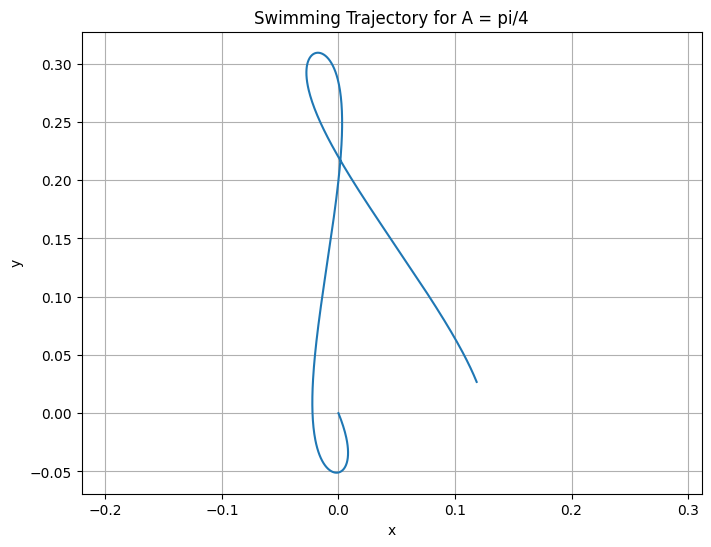

In [24]:
# Part 7 - Simulate Swimming with A = pi/4
# Gait Function
alpha_fcn = lambdify((t, omega, A1, A2, phi),[A1*sin(omega*t),
                                 A2*sin(omega*t +phi),
                                 diff(A1*sin(omega*t),t),
                                 diff(A2*sin(omega*t + phi),t)])
l_=1
k_=1
A_amp = np.pi/4
A1_   = A_amp
A2_   = A_amp
phi_  = np.pi/2
omega_= 2*np.pi
params_ = [l_, k_, A1_, A2_, omega_, phi_]

# Initial conditions [x, y, theta]
y0     = [0, 0, 0]
t_span = (0, 1)
t_eval = np.linspace(0, 1, 500)

# Solve
sol = solve_ivp(
    lambda t, y: dynamics(t, y, alpha_fcn, params_),
    t_span,
    y0,
    t_eval=t_eval,
    rtol=1e-8,
    atol=1e-8
)
# Plot x,y trajectory
plt.figure(figsize=(8, 6))
plt.plot(sol.y[0], sol.y[1])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Swimming Trajectory for A = pi/4')
plt.axis('equal')
plt.grid(True)
plt.show()

In [25]:
print(alpha_fcn(0.25, 2*np.pi, np.pi/4, np.pi/4, np.pi/2))

[np.float64(0.7853981633974483), np.float64(9.618353468608949e-17), np.float64(3.021694859661178e-16), np.float64(-4.934802200544679)]


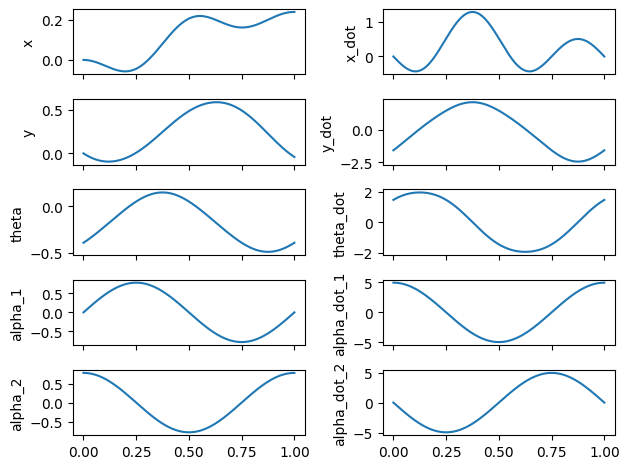

In [26]:
l_ = 2
w_ = 1
m_ = 1
k_ = 1
A1_ = np.pi/4
A2_ = A1_
omega_ = 2*np.pi
phi_ = np.pi/2
params_ = [l_, k_, A1_, A2_, omega_, phi_]

init_state = [0, 0, -np.pi/8]
t_end = 1
dt = 0.001
time = np.linspace(0, t_end, int(t_end/dt))

sol = solve_ivp(lambda t, y: dynamics(t, y, alpha_fcn, params_),
                [0, t_end], init_state,
                t_eval=time,
                rtol=1e-8, atol=1e-8)

# Fix: unpack params to call alpha_fcn correctly
l_, k_, A1_, A2_, omega_, phi_ = params_
alphas = alpha_fcn(time, omega_, A1_, A2_, phi_)

q_dots = sol.y * 0
for i, tim in enumerate(time):
    q_temp = dynamics(tim, sol.y[:, i], alpha_fcn, params_)
    q_dots[:, i] = q_temp

x_sol       = sol.y[0, :]
y_sol       = sol.y[1, :]
theta_sol   = sol.y[2, :]
x_dot_sol       = q_dots[0, :]
y_dot_sol       = q_dots[1, :]
theta_dot_sol   = q_dots[2, :]
alpha_0_sol     = alphas[0]
alpha_1_sol     = alphas[1]
alpha_0_dot_sol = alphas[2]
alpha_1_dot_sol = alphas[3]  # Fix: was alphas[2]

fig = plt.figure(2)
fig.clf()
ax = fig.subplots(5, 2, sharex=True)
ax[0][0].plot(time, x_sol);       ax[0][0].set_ylabel('x')
ax[1][0].plot(time, y_sol);       ax[1][0].set_ylabel('y')
ax[2][0].plot(time, theta_sol);   ax[2][0].set_ylabel('theta')
ax[3][0].plot(time, alpha_0_sol); ax[3][0].set_ylabel('alpha_1')
ax[4][0].plot(time, alpha_1_sol); ax[4][0].set_ylabel('alpha_2')
ax[0][1].plot(time, x_dot_sol);       ax[0][1].set_ylabel('x_dot')
ax[1][1].plot(time, y_dot_sol);       ax[1][1].set_ylabel('y_dot')
ax[2][1].plot(time, theta_dot_sol);   ax[2][1].set_ylabel('theta_dot')
ax[3][1].plot(time, alpha_0_dot_sol); ax[3][1].set_ylabel('alpha_dot_1')
ax[4][1].plot(time, alpha_1_dot_sol); ax[4][1].set_ylabel('alpha_dot_2')
plt.tight_layout()
plt.show()

### Part 8

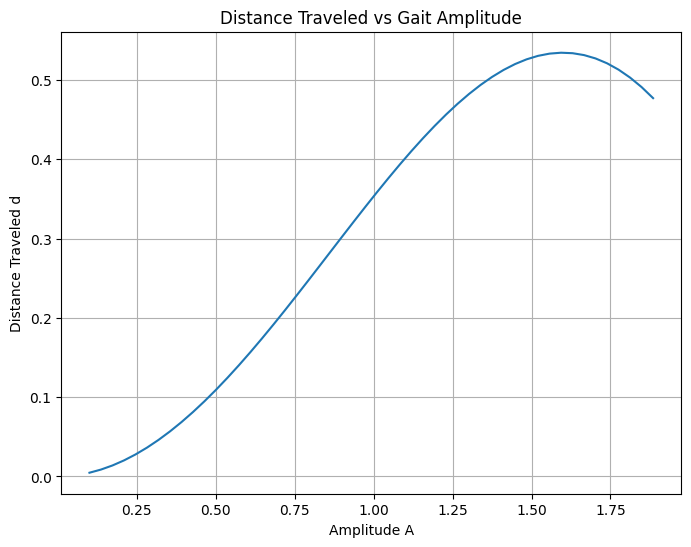

In [27]:
# Part 8 - Sweep Amplitude from 0.1 to 1.2*pi/2
A_vals = np.linspace(0.1, 1.2*np.pi/2, 50)
distances = []

phi_ = float(pi/2)

for A1_ in A_vals:

    # 1. build parameters
    A2_ = A1_
    params_ = [l_, k_, A1_, A2_, omega_, phi_]

    # 2. time setup
    init_state = [0, 0, 0]
    t_end = 1
    dt = 0.01
    time = np.linspace(0, t_end, int(t_end/dt))

    # 3. solve ODE
    sol = solve_ivp(
        lambda t, y: dynamics(t, y, alpha_fcn, params_),
        (0, t_end),
        init_state,
        t_eval=time,
        rtol=1e-8,
        atol=1e-8
    )

    # 4. recompute velocities (like screenshot does)
    q_dots = np.zeros((3, len(time)))

    for i, ti in enumerate(time):
        q_dots[:, i] = dynamics(ti, sol.y[:, i], alpha_fcn, params_)

    # 5. extract final position
    x_sol = sol.y[0, :]
    y_sol = sol.y[1, :]

    d = np.sqrt(x_sol[-1]**2 + y_sol[-1]**2)
    distances.append(d)
# Plot distance vs amplitude
plt.figure(figsize=(8, 6))
plt.plot(A_vals, distances)
plt.xlabel('Amplitude A')
plt.ylabel('Distance Traveled d')
plt.title('Distance Traveled vs Gait Amplitude')
plt.grid(True)
plt.show()

## Problem 2


In [28]:
import sympy as sp
from sympy import symbols, pprint, Function, simplify, Derivative, nsimplify
from sympy import sin, cos, asin, acos, pi, diff, eye
from sympy import Matrix, latex, BlockMatrix, lambdify
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from sympy import init_printing
init_printing() 

# Define Symbols
t  = symbols("t",   real=True)
l = symbols("l",  real=True)   # Length of Link, assume Links are same length
k = symbols("k", real=True) # Drag Coefficient
fpar= symbols("fpar", real=True)
fperp= symbols("fperp", real=True)
# Config Variables
x     = Function('x',     real=True)(t)
y     = Function('y',     real=True)(t)
theta = Function('theta', real=True)(t)
a1    = Function('a1',real=True)(t)
a2    = Function('a2',real=True)(t)
# Defining Various Helper Functions
def cross_matrix(vec):
    
    return Matrix([[0, -vec[2,0], vec[1,0]],
                      [vec[2,0], 0, -vec[0,0]],
                      [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    
    return Matrix([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    
    return(m)
    
def R_z(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta), -sin(theta), 0], 
                   [sin(theta), cos(theta), 0],
                   [0, 0, 1]])

def R_y(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta),0, sin(theta)], 
                   [0, 1, 0],
                   [-sin(theta), 0, cos(theta)]])

def R_x(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta), cos(theta)]])
def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m


### Part 1: Write a function to take a body twist vector and returns the body wrench

In [29]:
f_input= [fpar,fperp]
def bodywrench_from_Twist(Vb,f_input):
    epsilon = 1E-6
    fpar, fperp = f_input
    Fb= np.array([0,0,0,0,0], dtype=object)
    
    if Vb[3] < epsilon:
        Fb[3] = 2*fpar
    elif Vb[3] > epsilon:
        Fb[3] = fpar
    else:
        Fb[3] = 0

    if Vb[4] < epsilon:
        Fb[4] = -fperp
    elif Vb[4] > epsilon:
        Fb[4] = fperp
    else:
        Fb[4] = 0
    return Fb

### Part 2

In [30]:
# Body Twist For Each COM
params = [l,k,A1,A2,omega,phi]
q = [x,y,theta,a1,a2]
q_dt=[xdot,ydot,thetadot,a1dot,a2dot]
bodytwist1_lam = lambdify([t,q,q_dt],bodytwist_COM1)
bodytwist2_lam = lambdify([q,q_dt],bodytwist_COM2)
bodytwist3_lam = lambdify([q,q_dt],bodytwist_COM3)

# Lmabdify Jacobian
Jb1 = lambdify([q,q_dt,params],J1)
Jb2 = lambdify([q,q_dt,params],J2)
Jb3 = lambdify([q,q_dt,params],J3)

def netforce(q_, q_dt_, f_in, params_):
    # Evaluate body twists numerically
    bt1 = np.array(bodytwist1_lam(q_, q_dt_), dtype=float).flatten()
    bt2 = np.array(bodytwist2_lam(q_, q_dt_), dtype=float).flatten()
    bt3 = np.array(bodytwist3_lam(q_, q_dt_), dtype=float).flatten()
    
    # Get body wrenches for each link
    F1 = bodywrench_from_Twist(bt1, f_in)
    F2 = bodywrench_from_Twist(bt2, f_in)
    F3 = bodywrench_from_Twist(bt3, f_in)
    
    # Map wrenches back to generalized forces via Jacobians
    J1_ = np.array(Jb1(q_, q_dt_, params_), dtype=float)
    J2_ = np.array(Jb2(q_, q_dt_, params_), dtype=float)
    J3_ = np.array(Jb3(q_, q_dt_, params_), dtype=float)
    
    # Net generalized force = sum of J.T @ F for each link
    F_net = J1_.T @ F1 + J2_.T @ F2 + J3_.T @ F3
    
    return F_net

NameError: name 'xdot' is not defined

In [ ]:
print(bodytwist_COM1.free_symbols)

In [ ]:
# Numeric configuration and velocities
t_   = 0
q     = [x, y, theta, a1, a2]
q_dt  = [xd, yd, thetad, a1d, a2d]
f_in = [1, 1]

# Now safe to pass to bodywrench_from_Twist
sol1 = bodywrench_from_Twist(bodytwist1_lam, f_in)
sol2 = bodywrench_from_Twist(bodytwist2_lam, f_in)
sol3 = bodywrench_from_Twist(bodytwist3_lam, f_in)

net = sol1 + sol2 + sol3
net

### Part 3

In [ ]:
from scipy.optimize import fsolve
V0=np.zeros(3)
V_sol = fsolve(Vb, V0)

### Part 4